<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/session04-lab.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Session 4 lab: sequence alignment by hand, and a sequence logo {.unnumbered}

Four steps:

1. **By hand** (on paper, or in your head, not in this notebook): fill in
   a Needleman-Wunsch dynamic-programming matrix and trace back the
   optimal alignment, using a real substitution matrix. This notebook
   only *checks* your work, one small piece at a time -- it never
   computes the matrix for you.
2. **In code**: see how the score and the optimal alignment change as
   you vary the gap penalty and the substitution matrix -- first with
   the same small DP recurrence from Step 1, then with a real search of
   the Swiss-Prot database through a web API, to see how E-values (a
   database-search concept, not a two-sequence one) respond to the same
   kinds of changes.
3. **In code**: a small, real multiple sequence alignment -- built and
   visualized directly, not just described.
4. **By hand, then in code**: the entropy of alignment columns, and a
   sequence logo of a real protein family (the globins), to find the
   positions evolution has conserved.

Once all four steps are done, answer the Session 4 lab quiz on Canvas using
your own results.


## Setup: the exercise for Step 1

Align two real, short protein fragments by hand:

- **seqA = "HFGKE"** -- human beta-globin (HBB, UniProt `P68871`), residues 118-122
- **seqB = "HGQE"** -- human myoglobin (MYG, UniProt `P02144`), residues 25-28

Use a flat, linear gap penalty of **-4** per gap position, and the real
**BLOSUM62** substitution matrix (Henikoff & Henikoff, 1992) below,
restricted to just the residues that appear in these two fragments:

|     | E  | F  | G  | H  | K  | Q  |
|-----|---:|---:|---:|---:|---:|---:|
| **E** | 5 | -3 | -2 | 0 | 1 | 2 |
| **F** | -3 | 6 | -3 | -1 | -3 | -3 |
| **G** | -2 | -3 | 6 | -2 | -2 | -2 |
| **H** | 0 | -1 | -2 | 8 | -1 | 0 |
| **K** | 1 | -3 | -2 | -1 | 5 | 1 |
| **Q** | 2 | -3 | -2 | 0 | 1 | 5 |

The recurrence (same as the book page and the teaching notebook):

$$
S[i,j] = \max \begin{cases} S[i-1,j-1] + s(x_i, y_j) & \text{diagonal: match/mismatch} \\ S[i-1,j] + \text{gap} & \text{up: gap in seqB} \\ S[i,j-1] + \text{gap} & \text{left: gap in seqA} \end{cases}
$$

Run the setup cell below to get these same values programmatically (and
the mechanical border row/column already filled in) -- reading them
here first just means you don't have to execute anything to know what
the exercise even is.


In [1]:
import numpy as np

# Two real protein fragments -- not the same ones used anywhere else on
# the Session 4 page or its teaching notebook:
#   seqA = "HFGKE", human beta-globin (HBB, UniProt P68871), residues 118-122
#   seqB = "HGQE",  human myoglobin  (MYG, UniProt P02144), residues 25-28
seqA, seqB = "HFGKE", "HGQE"
gap = -4.0

# The real BLOSUM62 substitution matrix (Henikoff & Henikoff, 1992),
# restricted to just the residues that appear in seqA/seqB above --
# hardcoded here (rather than loaded via Biopython's
# Bio.Align.substitution_matrices) so this notebook has no dependency
# beyond NumPy/Matplotlib and runs in a stock Colab runtime with no
# `!pip install` step. Values confirmed against
# Bio.Align.substitution_matrices.load("BLOSUM62") while building this
# notebook.
BLOSUM62_SUB = {
    ('E', 'E'): 5, ('E', 'F'): -3, ('E', 'G'): -2, ('E', 'H'): 0, ('E', 'K'): 1, ('E', 'Q'): 2,
    ('F', 'E'): -3, ('F', 'F'): 6, ('F', 'G'): -3, ('F', 'H'): -1, ('F', 'K'): -3, ('F', 'Q'): -3,
    ('G', 'E'): -2, ('G', 'F'): -3, ('G', 'G'): 6, ('G', 'H'): -2, ('G', 'K'): -2, ('G', 'Q'): -2,
    ('H', 'E'): 0, ('H', 'F'): -1, ('H', 'G'): -2, ('H', 'H'): 8, ('H', 'K'): -1, ('H', 'Q'): 0,
    ('K', 'E'): 1, ('K', 'F'): -3, ('K', 'G'): -2, ('K', 'H'): -1, ('K', 'K'): 5, ('K', 'Q'): 1,
    ('Q', 'E'): 2, ('Q', 'F'): -3, ('Q', 'G'): -2, ('Q', 'H'): 0, ('Q', 'K'): 1, ('Q', 'Q'): 5,
}
blosum62 = BLOSUM62_SUB
residues = sorted(set(seqA) | set(seqB))

def score(a, b, subst=blosum62, gap_penalty=gap):
    if a == '-' or b == '-':
        return gap_penalty
    return subst[a, b]

print(f"seqA = {seqA!r}  ({len(seqA)} residues, human beta-globin fragment)")
print(f"seqB = {seqB!r}  ({len(seqB)} residues, human myoglobin fragment)")
print(f"gap penalty = {gap} (flat, linear -- same recurrence as the book page and teaching notebook)")
print()
print("BLOSUM62, restricted to just the residues appearing above (real values):")
print("     " + "  ".join(f"{r:>2}" for r in residues))
for r1 in residues:
    print(f"{r1:>2}  " + "  ".join(f"{blosum62[r1, r2]:>2}" for r2 in residues))
print()

m, n = len(seqA) + 1, len(seqB) + 1
S = np.full((m, n), np.nan)
for i in range(m):
    S[i, 0] = i * gap
for j in range(n):
    S[0, j] = j * gap

print("Border filled in (mechanical -- i*gap / j*gap), interior left for you to work out by hand:")
print("Rows = '-' + seqA, columns = '-' + seqB:")
print("        " + "     ".join(["-"] + list(seqB)))
for i, row_label in enumerate(["-"] + list(seqA)):
    print(row_label, " ", S[i])


seqA = 'HFGKE'  (5 residues, human beta-globin fragment)
seqB = 'HGQE'  (4 residues, human myoglobin fragment)
gap penalty = -4.0 (flat, linear -- same recurrence as the book page and teaching notebook)

BLOSUM62, restricted to just the residues appearing above (real values):
      E   F   G   H   K   Q
 E   5  -3  -2   0   1   2
 F  -3   6  -3  -1  -3  -3
 G  -2  -3   6  -2  -2  -2
 H   0  -1  -2   8  -1   0
 K   1  -3  -2  -1   5   1
 Q   2  -3  -2   0   1   5

Border filled in (mechanical -- i*gap / j*gap), interior left for you to work out by hand:
Rows = '-' + seqA, columns = '-' + seqB:
        -     H     G     Q     E
-   [ -0.  -4.  -8. -12. -16.]
H   [-4. nan nan nan nan]
F   [-8. nan nan nan nan]
G   [-12.  nan  nan  nan  nan]
K   [-16.  nan  nan  nan  nan]
E   [-20.  nan  nan  nan  nan]


## Step 1: fill in the matrix, one row at a time

Work out each row of the interior matrix by hand, then fill in that
row's cell below and run it to check just that row -- rather than
committing to all 20 values before getting any feedback at all. Row $i$
corresponds to `seqA[i-1]`, e.g. row 1 is `seqA[0] = 'H'`.


In [2]:
# Row 1 (seqA[0] = 'H'). Fill in S[1,1] through S[1,4].
row_1_guesses = {
    (1, 1): None, (1, 2): None, (1, 3): None, (1, 4): None,
}

def _real_matrix():
    real = S.copy()
    for i in range(1, m):
        for j in range(1, n):
            diag = real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = real[i-1, j] + gap
            left = real[i, j-1] + gap
            real[i, j] = max(diag, up, left)
    return real

_real = _real_matrix()

print("Checking row 1:")
_all_correct = True
for (i, j), guess in row_1_guesses.items():
    real_val = _real[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet")
        _all_correct = False
    elif float(guess) == real_val:
        print(f"  S[{i},{j}]: correct! ({real_val:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real_val:.0f}")
        _all_correct = False
print("Row 1 all correct -- move on to the next row." if _all_correct
      else "Fix row 1 and re-run this cell before moving on.")


Checking row 1:
  S[1,1]: not filled in yet
  S[1,2]: not filled in yet
  S[1,3]: not filled in yet
  S[1,4]: not filled in yet
Fix row 1 and re-run this cell before moving on.


In [3]:
# Row 2 (seqA[1] = 'F'). Fill in S[2,1] through S[2,4].
row_2_guesses = {
    (2, 1): None, (2, 2): None, (2, 3): None, (2, 4): None,
}

def _real_matrix():
    real = S.copy()
    for i in range(1, m):
        for j in range(1, n):
            diag = real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = real[i-1, j] + gap
            left = real[i, j-1] + gap
            real[i, j] = max(diag, up, left)
    return real

_real = _real_matrix()

print("Checking row 2:")
_all_correct = True
for (i, j), guess in row_2_guesses.items():
    real_val = _real[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet")
        _all_correct = False
    elif float(guess) == real_val:
        print(f"  S[{i},{j}]: correct! ({real_val:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real_val:.0f}")
        _all_correct = False
print("Row 2 all correct -- move on to the next row." if _all_correct
      else "Fix row 2 and re-run this cell before moving on.")


Checking row 2:
  S[2,1]: not filled in yet
  S[2,2]: not filled in yet
  S[2,3]: not filled in yet
  S[2,4]: not filled in yet
Fix row 2 and re-run this cell before moving on.


In [4]:
# Row 3 (seqA[2] = 'G'). Fill in S[3,1] through S[3,4].
row_3_guesses = {
    (3, 1): None, (3, 2): None, (3, 3): None, (3, 4): None,
}

def _real_matrix():
    real = S.copy()
    for i in range(1, m):
        for j in range(1, n):
            diag = real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = real[i-1, j] + gap
            left = real[i, j-1] + gap
            real[i, j] = max(diag, up, left)
    return real

_real = _real_matrix()

print("Checking row 3:")
_all_correct = True
for (i, j), guess in row_3_guesses.items():
    real_val = _real[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet")
        _all_correct = False
    elif float(guess) == real_val:
        print(f"  S[{i},{j}]: correct! ({real_val:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real_val:.0f}")
        _all_correct = False
print("Row 3 all correct -- move on to the next row." if _all_correct
      else "Fix row 3 and re-run this cell before moving on.")


Checking row 3:
  S[3,1]: not filled in yet
  S[3,2]: not filled in yet
  S[3,3]: not filled in yet
  S[3,4]: not filled in yet
Fix row 3 and re-run this cell before moving on.


In [5]:
# Row 4 (seqA[3] = 'K'). Fill in S[4,1] through S[4,4].
row_4_guesses = {
    (4, 1): None, (4, 2): None, (4, 3): None, (4, 4): None,
}

def _real_matrix():
    real = S.copy()
    for i in range(1, m):
        for j in range(1, n):
            diag = real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = real[i-1, j] + gap
            left = real[i, j-1] + gap
            real[i, j] = max(diag, up, left)
    return real

_real = _real_matrix()

print("Checking row 4:")
_all_correct = True
for (i, j), guess in row_4_guesses.items():
    real_val = _real[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet")
        _all_correct = False
    elif float(guess) == real_val:
        print(f"  S[{i},{j}]: correct! ({real_val:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real_val:.0f}")
        _all_correct = False
print("Row 4 all correct -- move on to the next row." if _all_correct
      else "Fix row 4 and re-run this cell before moving on.")


Checking row 4:
  S[4,1]: not filled in yet
  S[4,2]: not filled in yet
  S[4,3]: not filled in yet
  S[4,4]: not filled in yet
Fix row 4 and re-run this cell before moving on.


In [6]:
# Row 5 (seqA[4] = 'E'). Fill in S[5,1] through S[5,4].
row_5_guesses = {
    (5, 1): None, (5, 2): None, (5, 3): None, (5, 4): None,
}

def _real_matrix():
    real = S.copy()
    for i in range(1, m):
        for j in range(1, n):
            diag = real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = real[i-1, j] + gap
            left = real[i, j-1] + gap
            real[i, j] = max(diag, up, left)
    return real

_real = _real_matrix()

print("Checking row 5:")
_all_correct = True
for (i, j), guess in row_5_guesses.items():
    real_val = _real[i, j]
    if guess is None:
        print(f"  S[{i},{j}]: not filled in yet")
        _all_correct = False
    elif float(guess) == real_val:
        print(f"  S[{i},{j}]: correct! ({real_val:.0f})")
    else:
        print(f"  S[{i},{j}]: your guess {guess} does not match the real value {real_val:.0f}")
        _all_correct = False
print("Row 5 all correct -- move on to the next row." if _all_correct
      else "Fix row 5 and re-run this cell before moving on.")


Checking row 5:
  S[5,1]: not filled in yet
  S[5,2]: not filled in yet
  S[5,3]: not filled in yet
  S[5,4]: not filled in yet
Fix row 5 and re-run this cell before moving on.


### Now trace back

Once every row above checks out, trace back from the bottom-right
corner to the top-left, following the winning move at each cell, and
write out the two final aligned strings.


In [7]:
# Write out the two final aligned strings (use '-' for a gap). Format
# only -- this example is NOT the real answer for this exercise, just
# shows the shape expected: e.g. your_alignment = ("PQR", "P-R") would
# mean no gap in seqA and one gap in seqB (at the middle position) for a
# 3-letter seqA aligned to a 2-letter seqB. Work out the real one yourself.
your_alignment = (None, None)

def _real_traceback():
    trace = np.zeros((m, n, 2))
    for i in range(1, m):
        trace[i, 0, :] = (-1, 0)
    for j in range(1, n):
        trace[0, j, :] = (0, -1)
    for i in range(1, m):
        for j in range(1, n):
            diag = _real[i-1, j-1] + score(seqA[i-1], seqB[j-1])
            up = _real[i-1, j] + gap
            left = _real[i, j-1] + gap
            if diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    outA, outB = "", ""
    i, j = len(seqA), len(seqB)
    while i > 0 or j > 0:
        di, dj = trace[i, j]
        i, j = i + int(di), j + int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB

real_outA, real_outB = _real_traceback()

guessA, guessB = your_alignment
if guessA is None or guessB is None:
    print("Not filled in yet.")
elif guessA == real_outA and guessB == real_outB:
    print("Correct! Your traceback matches the real optimal alignment.")
    print(guessA)
    print(guessB)
else:
    print("Not quite -- the real alignment is:")
    print(real_outA)
    print(real_outB)
    print("(yours was:)")
    print(guessA)
    print(guessB)


Not filled in yet.


Once the row checks and the traceback check above all say "correct,"
Step 1 is done -- you have the full matrix, the final score, and the
final alignment.


## Step 2: how do the score and alignment change with different parameters?

This step is exploratory, not another by-hand check -- run the cells
and look at real results. Same `seqA`/`seqB` as Step 1, but now scored
in code across a few different gap penalties and substitution matrices,
to see directly how much the choice of parameters actually matters.


In [8]:
def global_align(seqA, seqB, gap, subst):
    """Same Needleman-Wunsch recurrence as Step 1 and the teaching notebook,
    generalized to take any gap penalty / substitution matrix."""
    m, n = len(seqA) + 1, len(seqB) + 1
    S = np.zeros((m, n))
    trace = np.zeros((m, n, 2))
    for i in range(1, m):
        S[i, 0] = i * gap
        trace[i, 0, :] = (-1, 0)
    for j in range(1, n):
        S[0, j] = j * gap
        trace[0, j, :] = (0, -1)
    for i in range(1, m):
        for j in range(1, n):
            diag = S[i-1, j-1] + subst(seqA[i-1], seqB[j-1])
            up = S[i-1, j] + gap
            left = S[i, j-1] + gap
            S[i, j] = max(diag, up, left)
            if diag >= max(up, left):
                trace[i, j, :] = (-1, -1)
            elif up >= left:
                trace[i, j, :] = (-1, 0)
            else:
                trace[i, j, :] = (0, -1)
    return S, trace

def traceback(seqA, seqB, S, trace):
    i, j = len(seqA), len(seqB)
    outA, outB = "", ""
    while i > 0 or j > 0:
        di, dj = trace[i, j]
        i, j = i + int(di), j + int(dj)
        outA = ("-" if di == 0 else seqA[i]) + outA
        outB = ("-" if dj == 0 else seqB[j]) + outB
    return outA, outB

# The real PAM250 substitution matrix (Dayhoff, Schwartz & Orcutt, 1978),
# restricted to the same 6 residues -- values confirmed against
# Bio.Align.substitution_matrices.load("PAM250"), same approach as
# BLOSUM62 above (hardcoded, no Biopython dependency).
PAM250_SUB = {
    ('E', 'E'): 4, ('E', 'F'): -5, ('E', 'G'): 0, ('E', 'H'): 1, ('E', 'K'): 0, ('E', 'Q'): 2,
    ('F', 'E'): -5, ('F', 'F'): 9, ('F', 'G'): -5, ('F', 'H'): -2, ('F', 'K'): -5, ('F', 'Q'): -5,
    ('G', 'E'): 0, ('G', 'F'): -5, ('G', 'G'): 5, ('G', 'H'): -2, ('G', 'K'): -2, ('G', 'Q'): -1,
    ('H', 'E'): 1, ('H', 'F'): -2, ('H', 'G'): -2, ('H', 'H'): 6, ('H', 'K'): 0, ('H', 'Q'): 3,
    ('K', 'E'): 0, ('K', 'F'): -5, ('K', 'G'): -2, ('K', 'H'): 0, ('K', 'K'): 5, ('K', 'Q'): 1,
    ('Q', 'E'): 2, ('Q', 'F'): -5, ('Q', 'G'): -1, ('Q', 'H'): 3, ('Q', 'K'): 1, ('Q', 'Q'): 4,
}

# A wider BLOSUM62 sub-table (17 residues) -- Step 1's small 6-residue
# BLOSUM62_SUB above only covers seqA/seqB's own letters; Step 3's MSA
# below uses more residues, so this covers both. Same approach: hardcoded,
# confirmed against Bio.Align.substitution_matrices.load("BLOSUM62").
BLOSUM62_WIDE = {
    ('A', 'A'): 4, ('A', 'D'): -2, ('A', 'E'): -1, ('A', 'F'): -2, ('A', 'G'): 0, ('A', 'H'): -2, ('A', 'I'): -1, ('A', 'K'): -1, ('A', 'L'): -1, ('A', 'N'): -2, ('A', 'P'): -1, ('A', 'Q'): -1, ('A', 'S'): 1, ('A', 'T'): 0, ('A', 'V'): 0, ('A', 'W'): -3, ('A', 'Y'): -2,
    ('D', 'A'): -2, ('D', 'D'): 6, ('D', 'E'): 2, ('D', 'F'): -3, ('D', 'G'): -1, ('D', 'H'): -1, ('D', 'I'): -3, ('D', 'K'): -1, ('D', 'L'): -4, ('D', 'N'): 1, ('D', 'P'): -1, ('D', 'Q'): 0, ('D', 'S'): 0, ('D', 'T'): -1, ('D', 'V'): -3, ('D', 'W'): -4, ('D', 'Y'): -3,
    ('E', 'A'): -1, ('E', 'D'): 2, ('E', 'E'): 5, ('E', 'F'): -3, ('E', 'G'): -2, ('E', 'H'): 0, ('E', 'I'): -3, ('E', 'K'): 1, ('E', 'L'): -3, ('E', 'N'): 0, ('E', 'P'): -1, ('E', 'Q'): 2, ('E', 'S'): 0, ('E', 'T'): -1, ('E', 'V'): -2, ('E', 'W'): -3, ('E', 'Y'): -2,
    ('F', 'A'): -2, ('F', 'D'): -3, ('F', 'E'): -3, ('F', 'F'): 6, ('F', 'G'): -3, ('F', 'H'): -1, ('F', 'I'): 0, ('F', 'K'): -3, ('F', 'L'): 0, ('F', 'N'): -3, ('F', 'P'): -4, ('F', 'Q'): -3, ('F', 'S'): -2, ('F', 'T'): -2, ('F', 'V'): -1, ('F', 'W'): 1, ('F', 'Y'): 3,
    ('G', 'A'): 0, ('G', 'D'): -1, ('G', 'E'): -2, ('G', 'F'): -3, ('G', 'G'): 6, ('G', 'H'): -2, ('G', 'I'): -4, ('G', 'K'): -2, ('G', 'L'): -4, ('G', 'N'): 0, ('G', 'P'): -2, ('G', 'Q'): -2, ('G', 'S'): 0, ('G', 'T'): -2, ('G', 'V'): -3, ('G', 'W'): -2, ('G', 'Y'): -3,
    ('H', 'A'): -2, ('H', 'D'): -1, ('H', 'E'): 0, ('H', 'F'): -1, ('H', 'G'): -2, ('H', 'H'): 8, ('H', 'I'): -3, ('H', 'K'): -1, ('H', 'L'): -3, ('H', 'N'): 1, ('H', 'P'): -2, ('H', 'Q'): 0, ('H', 'S'): -1, ('H', 'T'): -2, ('H', 'V'): -3, ('H', 'W'): -2, ('H', 'Y'): 2,
    ('I', 'A'): -1, ('I', 'D'): -3, ('I', 'E'): -3, ('I', 'F'): 0, ('I', 'G'): -4, ('I', 'H'): -3, ('I', 'I'): 4, ('I', 'K'): -3, ('I', 'L'): 2, ('I', 'N'): -3, ('I', 'P'): -3, ('I', 'Q'): -3, ('I', 'S'): -2, ('I', 'T'): -1, ('I', 'V'): 3, ('I', 'W'): -3, ('I', 'Y'): -1,
    ('K', 'A'): -1, ('K', 'D'): -1, ('K', 'E'): 1, ('K', 'F'): -3, ('K', 'G'): -2, ('K', 'H'): -1, ('K', 'I'): -3, ('K', 'K'): 5, ('K', 'L'): -2, ('K', 'N'): 0, ('K', 'P'): -1, ('K', 'Q'): 1, ('K', 'S'): 0, ('K', 'T'): -1, ('K', 'V'): -2, ('K', 'W'): -3, ('K', 'Y'): -2,
    ('L', 'A'): -1, ('L', 'D'): -4, ('L', 'E'): -3, ('L', 'F'): 0, ('L', 'G'): -4, ('L', 'H'): -3, ('L', 'I'): 2, ('L', 'K'): -2, ('L', 'L'): 4, ('L', 'N'): -3, ('L', 'P'): -3, ('L', 'Q'): -2, ('L', 'S'): -2, ('L', 'T'): -1, ('L', 'V'): 1, ('L', 'W'): -2, ('L', 'Y'): -1,
    ('N', 'A'): -2, ('N', 'D'): 1, ('N', 'E'): 0, ('N', 'F'): -3, ('N', 'G'): 0, ('N', 'H'): 1, ('N', 'I'): -3, ('N', 'K'): 0, ('N', 'L'): -3, ('N', 'N'): 6, ('N', 'P'): -2, ('N', 'Q'): 0, ('N', 'S'): 1, ('N', 'T'): 0, ('N', 'V'): -3, ('N', 'W'): -4, ('N', 'Y'): -2,
    ('P', 'A'): -1, ('P', 'D'): -1, ('P', 'E'): -1, ('P', 'F'): -4, ('P', 'G'): -2, ('P', 'H'): -2, ('P', 'I'): -3, ('P', 'K'): -1, ('P', 'L'): -3, ('P', 'N'): -2, ('P', 'P'): 7, ('P', 'Q'): -1, ('P', 'S'): -1, ('P', 'T'): -1, ('P', 'V'): -2, ('P', 'W'): -4, ('P', 'Y'): -3,
    ('Q', 'A'): -1, ('Q', 'D'): 0, ('Q', 'E'): 2, ('Q', 'F'): -3, ('Q', 'G'): -2, ('Q', 'H'): 0, ('Q', 'I'): -3, ('Q', 'K'): 1, ('Q', 'L'): -2, ('Q', 'N'): 0, ('Q', 'P'): -1, ('Q', 'Q'): 5, ('Q', 'S'): 0, ('Q', 'T'): -1, ('Q', 'V'): -2, ('Q', 'W'): -2, ('Q', 'Y'): -1,
    ('S', 'A'): 1, ('S', 'D'): 0, ('S', 'E'): 0, ('S', 'F'): -2, ('S', 'G'): 0, ('S', 'H'): -1, ('S', 'I'): -2, ('S', 'K'): 0, ('S', 'L'): -2, ('S', 'N'): 1, ('S', 'P'): -1, ('S', 'Q'): 0, ('S', 'S'): 4, ('S', 'T'): 1, ('S', 'V'): -2, ('S', 'W'): -3, ('S', 'Y'): -2,
    ('T', 'A'): 0, ('T', 'D'): -1, ('T', 'E'): -1, ('T', 'F'): -2, ('T', 'G'): -2, ('T', 'H'): -2, ('T', 'I'): -1, ('T', 'K'): -1, ('T', 'L'): -1, ('T', 'N'): 0, ('T', 'P'): -1, ('T', 'Q'): -1, ('T', 'S'): 1, ('T', 'T'): 5, ('T', 'V'): 0, ('T', 'W'): -2, ('T', 'Y'): -2,
    ('V', 'A'): 0, ('V', 'D'): -3, ('V', 'E'): -2, ('V', 'F'): -1, ('V', 'G'): -3, ('V', 'H'): -3, ('V', 'I'): 3, ('V', 'K'): -2, ('V', 'L'): 1, ('V', 'N'): -3, ('V', 'P'): -2, ('V', 'Q'): -2, ('V', 'S'): -2, ('V', 'T'): 0, ('V', 'V'): 4, ('V', 'W'): -3, ('V', 'Y'): -1,
    ('W', 'A'): -3, ('W', 'D'): -4, ('W', 'E'): -3, ('W', 'F'): 1, ('W', 'G'): -2, ('W', 'H'): -2, ('W', 'I'): -3, ('W', 'K'): -3, ('W', 'L'): -2, ('W', 'N'): -4, ('W', 'P'): -4, ('W', 'Q'): -2, ('W', 'S'): -3, ('W', 'T'): -2, ('W', 'V'): -3, ('W', 'W'): 11, ('W', 'Y'): 2,
    ('Y', 'A'): -2, ('Y', 'D'): -3, ('Y', 'E'): -2, ('Y', 'F'): 3, ('Y', 'G'): -3, ('Y', 'H'): 2, ('Y', 'I'): -1, ('Y', 'K'): -2, ('Y', 'L'): -1, ('Y', 'N'): -2, ('Y', 'P'): -3, ('Y', 'Q'): -1, ('Y', 'S'): -2, ('Y', 'T'): -2, ('Y', 'V'): -1, ('Y', 'W'): 2, ('Y', 'Y'): 7,
}


def identity_score(a, b):
    return 1.0 if a == b else -1.0

def blosum62_score(a, b):
    return BLOSUM62_WIDE[a, b]

def pam250_score(a, b):
    return PAM250_SUB[a, b]

print("Varying the gap penalty (BLOSUM62 fixed):")
for gap_test in [-1.0, -4.0, -8.0, -12.0]:
    S_t, tr_t = global_align(seqA, seqB, gap_test, blosum62_score)
    oA, oB = traceback(seqA, seqB, S_t, tr_t)
    print(f"  gap={gap_test:>6.1f}  score={S_t[-1,-1]:>5.0f}   {oA} / {oB}")

print()
print("Varying the substitution matrix (gap=-4 fixed):")
for label, subst in [("identity", identity_score), ("BLOSUM62", blosum62_score), ("PAM250", pam250_score)]:
    S_t, tr_t = global_align(seqA, seqB, -4.0, subst)
    oA, oB = traceback(seqA, seqB, S_t, tr_t)
    print(f"  {label:>8s}  score={S_t[-1,-1]:>5.0f}   {oA} / {oB}")


Varying the gap penalty (BLOSUM62 fixed):
  gap=  -1.0  score=   19   HFGKE / H-GQE
  gap=  -4.0  score=   16   HFGKE / H-GQE
  gap=  -8.0  score=   12   HFGKE / H-GQE
  gap= -12.0  score=    8   HFGKE / H-GQE

Varying the substitution matrix (gap=-4 fixed):
  identity  score=   -2   HFGKE / H-GQE
  BLOSUM62  score=   16   HFGKE / H-GQE
    PAM250  score=   12   HFGKE / H-GQE


### E-values: a database-search concept, shown against a real database

An **E-value** does not come from a two-sequence alignment score by
itself. It is the number of hits this good or better that you would
expect by chance when searching *a database of a given size*, so it
needs a real database and the statistics of a real search tool, not just
the DP recurrence above.

This part therefore searches a real database through a **web API**: the
query is sent to a server at EMBL-EBI, which runs the search and sends
the result back, so nothing has to be installed. The tool is **phmmer**
from the HMMER package, which searches one protein sequence against a
database much as BLAST does (Session 5 covers BLAST and HMMER properly).
The query is human beta-globin (HBB), the database is UniProtKB/Swiss-Prot
(about 500,000 reviewed proteins), and only the human hits are listed.
Look in particular at four relatives used throughout this course:
alpha-globin (HBA1), myoglobin (MB), neuroglobin (NGB) and cytoglobin
(CYGB).

phmmer turns the substitution matrix into probabilities, and describes
gaps the same way: `popen` is the probability of opening a gap (default
0.02) and `pextend` the probability of extending one (default 0.4). A
*larger* `popen` therefore means *cheaper* gaps, the opposite of a gap
penalty.


In [9]:
import time
import requests

HMMER = "https://www.ebi.ac.uk/Tools/hmmer/api/v1"

def phmmer(sequence, database="swissprot", taxonomy=None, max_wait=120, **options):
    """Search one protein sequence against a database with EBI's HMMER web API; return the result as a dict."""
    query = {"input": ">query\n" + sequence, "database": database, **options}
    if taxonomy:
        query["include_taxonomy"] = [taxonomy]      # list only hits from this taxon (the E-values still use the whole database)
    r = requests.post(f"{HMMER}/search/phmmer", json=query, timeout=60)
    r.raise_for_status()
    job = r.json()["id"]
    start = time.time()
    while True:                                     # wait for the search to finish (usually a second or two)
        result = requests.get(f"{HMMER}/result/{job}", params={"page_size": 1000}, timeout=60).json()
        if result["status"] == "SUCCESS":
            return result["result"]
        if result["status"] == "FAILURE" or time.time() - start > max_wait:
            raise RuntimeError(f"The HMMER server did not finish job {job} (status {result['status']}). Wait a minute and run the cell again.")
        time.sleep(1)

HBB = ("MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH")
RELATIVES = {"HBA_HUMAN": "HBA1", "MYG_HUMAN": "MB", "NGB_HUMAN": "NGB", "CYGB_HUMAN": "CYGB"}

def show(result):
    for hit in result["hits"]:
        name = hit["metadata"]["identifier"]
        mark = f"  <- {RELATIVES[name]}" if name in RELATIVES else ""
        print(f"  {name:<12} {hit['metadata']['description'][:34]:<34} bit score {hit['score']:6.1f}   E-value {hit['evalue']:9.2g}{mark}")

default = phmmer(HBB, taxonomy=9606)
print(f"phmmer, HBB against {default['stats']['nseqs']:,} Swiss-Prot sequences; human hits with E < 1:")
show(default)

phmmer, HBB against 503,053 Swiss-Prot sequences; human hits with E < 1:
  HBB_HUMAN    Hemoglobin subunit beta            bit score  332.8   E-value   6.1e-99
  HBD_HUMAN    Hemoglobin subunit delta           bit score  308.8   E-value   1.5e-91
  HBE_HUMAN    Hemoglobin subunit epsilon         bit score  253.8   E-value   1.3e-74
  HBG2_HUMAN   Hemoglobin subunit gamma-2         bit score  248.1   E-value   7.9e-73
  HBG1_HUMAN   Hemoglobin subunit gamma-1         bit score  243.9   E-value   1.5e-71
  HBA_HUMAN    Hemoglobin subunit alpha           bit score  106.4   E-value   3.4e-29  <- HBA1
  HBAZ_HUMAN   Hemoglobin subunit zeta            bit score   86.7   E-value   4.1e-23
  HBAT_HUMAN   Hemoglobin subunit theta-1         bit score   83.3   E-value   4.7e-22
  HBM_HUMAN    Hemoglobin subunit mu              bit score   74.2   E-value     3e-19
  CYGB_HUMAN   Cytoglobin                         bit score   58.1   E-value   2.8e-14  <- CYGB
  MYG_HUMAN    Myoglobin               

Only twelve human proteins are found, all of them globins. HBB's
own entry comes first, then the other beta-like haemoglobin chains
(delta, epsilon, gamma). Alpha-globin comes among the alpha-like chains,
and cytoglobin, myoglobin and neuroglobin, the most distant relatives,
come last.

**Where the E-value comes from.** phmmer computes, for each hit, the
probability $P$ that an unrelated sequence would score this well, and
then multiplies by the number of sequences searched: $E = N \cdot P$.
The next cell checks this for the four relatives. A database ten times
larger would give every hit an E-value ten times larger, although the
alignment itself would not change at all.


In [10]:
import math

N = default["stats"]["nseqs"]
print(f"N = {N:,} sequences searched\n")
for hit in default["hits"]:
    name = hit["metadata"]["identifier"]
    if name in RELATIVES:
        P = math.exp(hit["lnP"])                    # HMMER reports ln(P), because P is often too small for a float
        print(f"  {RELATIVES[name]:<5} P = {P:9.2g}   N x P = {N * P:9.2g}   reported E-value = {hit['evalue']:9.2g}")

N = 503,053 sequences searched

  HBA1  P =   6.9e-35   N x P =   3.4e-29   reported E-value =   3.4e-29
  CYGB  P =   5.5e-20   N x P =   2.8e-14   reported E-value =   2.8e-14
  MB    P =   4.2e-12   N x P =   2.1e-06   reported E-value =   2.1e-06
  NGB   P =     3e-09   N x P =    0.0015   reported E-value =    0.0015


### The same search with other parameters

Now the same search, varying the two kinds of parameters from the first
half of Step 2: the gap parameters (with BLOSUM62) and the substitution
matrix (with the default gaps). Each search takes a second or two.


In [11]:
def relatives_line(result):
    found = {h["metadata"]["identifier"]: h["evalue"] for h in result["hits"]}
    return "  ".join(f"{short}: {found[name]:8.2g}" if name in found else f"{short}: {'not found':>8}"
                     for name, short in RELATIVES.items())

print("Gap parameters (BLOSUM62):")
for popen, pextend in [(0.02, 0.4), (0.01, 0.4), (0.04, 0.4), (0.02, 0.6)]:
    result = phmmer(HBB, taxonomy=9606, popen=popen, pextend=pextend)
    print(f"  popen={popen:<5} pextend={pextend:<4}  {relatives_line(result)}")

print()
print("Substitution matrix (default gaps):")
for matrix in ["BLOSUM45", "BLOSUM62", "BLOSUM90", "PAM30"]:
    result = phmmer(HBB, taxonomy=9606, mx=matrix)
    print(f"  {matrix:<9}                  {relatives_line(result)}")

Gap parameters (BLOSUM62):


  popen=0.02  pextend=0.4   HBA1:  3.4e-29  MB:  2.1e-06  NGB:   0.0015  CYGB:  2.8e-14


  popen=0.01  pextend=0.4   HBA1:  1.4e-29  MB:  4.7e-07  NGB:   0.0013  CYGB:    1e-14


  popen=0.04  pextend=0.4   HBA1:  1.2e-27  MB:  3.8e-05  NGB:   0.0092  CYGB:  7.4e-13


  popen=0.02  pextend=0.6   HBA1:  1.3e-29  MB:    3e-06  NGB:   0.0022  CYGB:  2.2e-14

Substitution matrix (default gaps):


  BLOSUM45                   HBA1:  5.4e-25  MB:  2.8e-06  NGB:  0.00047  CYGB:  3.4e-13


  BLOSUM62                   HBA1:  3.4e-29  MB:  2.1e-06  NGB:   0.0015  CYGB:  2.8e-14


  BLOSUM90                   HBA1:    2e-33  MB:   0.0097  NGB: not found  CYGB:  6.1e-12


  PAM30                      HBA1:  2.3e-22  MB: not found  NGB: not found  CYGB: not found


The gap parameters change the E-values of the distant relatives, by a
factor of almost a hundred for myoglobin, but every relative is still
found. The
substitution matrix matters much more. BLOSUM45 and BLOSUM62, built
from distantly related sequences, find all four relatives. BLOSUM90,
built from close relatives, loses neuroglobin. **PAM30**, a matrix made
for very similar sequences, loses myoglobin, neuroglobin and cytoglobin
altogether, although they are real homologs with the same fold. The
matrix encodes what kind of relatives you are looking for, which is the
same parameter sensitivity as in the small DP example above, now in a
real database search. Session 5 explains BLAST, HMMER and E-values
properly.


## Step 3: a simple multiple sequence alignment

The book page's own "Multiple sequence alignment" section describes the
**progressive** strategy (align the closest pair first, then bring in
each further sequence guided by the pairwise similarities) but only
shows a guide tree, not an actual alignment. This builds one, on three
real, short windows (the same conserved `WGKV` motif region used
elsewhere on the Session 4 page) from three real proteins already used
throughout this course:

- **HBA1** (alpha-globin), **MB** (myoglobin), and **HBB** (beta-globin)
  -- residues 9-28 (HBA1/MB) or 10-29 (HBB) of each, fetched from
  UniProt while building this notebook.

This is a deliberately simplified, from-scratch demonstration of the
*progressive* strategy using the same pairwise `global_align` from Step
2 -- not a production MSA tool (a real tool like MUSCLE or Clustal Omega
handles profile-vs-profile scoring, affine gap costs, and iterative
refinement; this only aligns the closest pair, then merges in the third
sequence against whichever of the first two it's closer to).


In [12]:
# The same conserved-motif windows used in the "Real substitution
# matrices" section of the teaching notebook, extended to a third
# sequence -- real 20-residue windows from UniProt, all containing the
# WGKV motif:
MSA_WINDOWS = {
    "HBA1": "TNVKAAWGKVGAHAGEYGAE",  # P69905, residues 9-28
    "MB":   "QLVLNVWGKVEADIPGHGQE",  # P02144, residues 9-28
    "HBB":  "SAVTALWGKVNVDEVGGEAL",  # P68871, residues 10-29
}

def pairwise_score(a, b):
    S_ab, _ = global_align(a, b, -6.0, blosum62_score)
    return S_ab[-1, -1]

# Step A: find the closest pair by real pairwise score.
names = list(MSA_WINDOWS)
best_pair, best_score = None, -np.inf
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        s = pairwise_score(MSA_WINDOWS[names[i]], MSA_WINDOWS[names[j]])
        print(f"  pairwise score {names[i]}-{names[j]}: {s:.0f}")
        if s > best_score:
            best_score, best_pair = s, (names[i], names[j])
print(f"Closest pair: {best_pair[0]}-{best_pair[1]} (score {best_score:.0f}) -- align these first.")

n1, n2 = best_pair
n3 = [n for n in names if n not in best_pair][0]

S12, tr12 = global_align(MSA_WINDOWS[n1], MSA_WINDOWS[n2], -6.0, blosum62_score)
a1, a2 = traceback(MSA_WINDOWS[n1], MSA_WINDOWS[n2], S12, tr12)
profile = {n1: a1, n2: a2}

# Step B: which of n1/n2 is the third sequence more similar to? Align
# the third sequence against that one's RAW (ungapped) sequence.
ref = n1 if pairwise_score(MSA_WINDOWS[n3], MSA_WINDOWS[n1]) >= pairwise_score(MSA_WINDOWS[n3], MSA_WINDOWS[n2]) else n2
S3r, tr3r = global_align(MSA_WINDOWS[n3], MSA_WINDOWS[ref], -6.0, blosum62_score)
a3, a_ref_new = traceback(MSA_WINDOWS[n3], MSA_WINDOWS[ref], S3r, tr3r)
print(f"Aligning in {n3!r} against {ref!r} (its closer of the two already-aligned sequences).")

# Step C: merge -- walk the OLD aligned reference row and the FRESH
# aligned reference row together; wherever one has a gap the other
# doesn't, pad every other row accordingly. (A simplified version of the
# real "once a gap, always a gap" progressive-alignment merge rule.)
def merge_profile(profile_rows, ref_name, new_ref_aligned, new_seq_aligned):
    old_ref = profile_rows[ref_name]
    cols = {name: [] for name in profile_rows}
    cols["__NEW__"] = []
    i = j = 0
    while i < len(old_ref) or j < len(new_ref_aligned):
        old_c = old_ref[i] if i < len(old_ref) else None
        new_c = new_ref_aligned[j] if j < len(new_ref_aligned) else None
        if old_c == '-' and new_c != '-':
            for name, row in profile_rows.items():
                cols[name].append(row[i])
            cols["__NEW__"].append('-')
            i += 1
        elif new_c == '-' and old_c != '-':
            for name, row in profile_rows.items():
                cols[name].append('-')
            cols["__NEW__"].append(new_seq_aligned[j])
            j += 1
        else:
            for name, row in profile_rows.items():
                cols[name].append(row[i])
            cols["__NEW__"].append(new_seq_aligned[j])
            i += 1
            j += 1
    return {name: "".join(c) for name, c in cols.items()}

merged = merge_profile(profile, ref, a_ref_new, a3)
merged[n3] = merged.pop("__NEW__")

print()
print("Final progressive MSA:")
for name in names:
    print(f"  {name:5s} {merged[name]}")

msa_result = merged  # used by the visualization cell below


  pairwise score HBA1-MB: 30
  pairwise score HBA1-HBB: 22
  pairwise score MB-HBB: 29
Closest pair: HBA1-MB (score 30) -- align these first.
Aligning in 'HBB' against 'MB' (its closer of the two already-aligned sequences).

Final progressive MSA:
  HBA1  TNVKAAWGKVGAHAGEYGAE-
  MB    QLVLNVWGKVEADIPGHGQE-
  HBB   SAVTALWGKVNVDEVG-GEAL


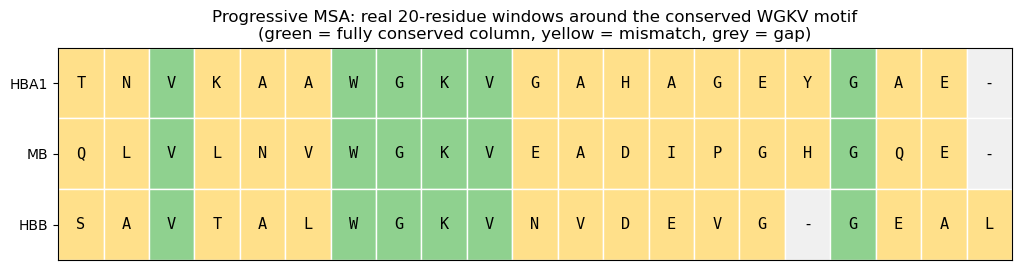

In [13]:
import matplotlib.pyplot as plt

names_order = list(msa_result)
ncols = len(next(iter(msa_result.values())))

fig, ax = plt.subplots(figsize=(0.42 * ncols + 1.5, 0.6 * len(names_order) + 1))
for row, name in enumerate(names_order):
    seq = msa_result[name]
    for col, ch in enumerate(seq):
        others = [msa_result[n][col] for n in names_order if n != name]
        if ch == '-':
            color = "#f0f0f0"
        elif all(ch == o for o in others):
            color = "#8fd18f"
        else:
            color = "#ffe08a"
        ax.add_patch(plt.Rectangle((col, len(names_order) - 1 - row), 1, 1,
                                    facecolor=color, edgecolor="white"))
        ax.text(col + 0.5, len(names_order) - 1 - row + 0.5, ch,
                ha="center", va="center", fontsize=11, family="monospace")
ax.set_xlim(0, ncols)
ax.set_ylim(0, len(names_order))
ax.set_yticks([len(names_order) - 1 - i + 0.5 for i in range(len(names_order))])
ax.set_yticklabels(names_order)
ax.set_xticks([])
ax.set_title("Progressive MSA: real 20-residue windows around the conserved WGKV motif\n"
              "(green = fully conserved column, yellow = mismatch, grey = gap)")
plt.tight_layout()
plt.show()


## Step 4: reading an alignment -- entropy and a sequence logo

The book page's "Reading an alignment: entropy and sequence logos"
section summarizes each column of a multiple alignment by its
**entropy** (Session 1), $H = -\sum_a p_a \log_2 p_a$: 0 bits for a
fully conserved column, higher the more the column varies. A **sequence
logo** draws each column as a stack of letters whose height is the
column's information content, $\log_2 20 - H$.

### 4a. By hand: the entropy of three columns

The cell below picks three columns from your Step 3 alignment: one where
all three sequences agree, one where two agree, and one where all three
differ. Work out the entropy of each **by hand** (in bits) before you run
the check.

In [14]:
# Pick three columns from the Step 3 MSA (msa_result), by how many different residues they contain
columns = ["".join(msa_result[n][c] for n in msa_result) for c in range(len(next(iter(msa_result.values()))))]
picked = {}
for c, col in enumerate(columns):
    if "-" in col:
        continue
    kind = {1: "all same", 2: "two same, one different", 3: "all different"}[len(set(col))]
    picked.setdefault(kind, (c + 1, col))
for kind in ["all same", "two same, one different", "all different"]:
    c, col = picked[kind]
    print(f"column {c:2d}: {' '.join(col)}   ({kind})")

column  3: V V V   (all same)
column  5: A N A   (two same, one different)
column  1: T Q S   (all different)


In [15]:
# Replace each None with the entropy you worked out, in bits (two decimals is enough).
entropy_guesses = {
    "all same": None,
    "two same, one different": None,
    "all different": None,
}

def column_entropy(col):
    """Entropy in bits of the residues in one alignment column (gaps ignored)."""
    residues = [r for r in col if r != "-"]
    freqs = np.array([residues.count(r) for r in set(residues)]) / len(residues)
    return float(-(freqs * np.log2(freqs)).sum()) + 0.0   # + 0.0 turns -0.0 into 0.0

for kind, guess in entropy_guesses.items():
    real = column_entropy(picked[kind][1])
    if guess is None:
        print(f"{kind:25s}: not filled in yet")
    else:
        print(f"{kind:25s}: your answer {guess:.2f}, real {real:.2f} -> "
              f"{'correct' if abs(guess - real) < 0.01 else 'not quite, check your logs'}")

all same                 : not filled in yet
two same, one different  : not filled in yet
all different            : not filled in yet


With three sequences, a column can never have more than
$\log_2 3 \approx 1.58$ bits of entropy, however variable the position
really is, and three identical residues can be a coincidence. To see
which positions a protein family really conserves, you need many
sequences.

### 4b. A real family: the Pfam globin seed alignment

The Pfam database keeps a curated "seed" alignment for each protein
family. The globin seed has 73 globins, from bacteria, plants, worms,
insects and vertebrates. The cell downloads it from InterPro (or uses a
cached copy if the download fails) and reads the Stockholm format, one
`name  aligned-sequence` line per sequence.

In [16]:
import gzip, io, os, urllib.request

URL = "https://www.ebi.ac.uk/interpro/api/entry/pfam/PF00042/?annotation=alignment:seed"
CACHE = "session04-globin-seed.sto"
CACHE_URL = "https://raw.githubusercontent.com/ElofssonLab/kb8029-book/main/notebooks/data/" + CACHE

def fetch(url):
    with urllib.request.urlopen(url, timeout=60) as r:
        data = r.read()
    return gzip.decompress(data).decode() if data[:2] == b"\x1f\x8b" else data.decode()

try:
    text, source = fetch(URL), "InterPro (live)"
except Exception as err:
    print("InterPro not reachable:", err)
    path = os.path.join("data", CACHE)
    text = open(path).read() if os.path.exists(path) else fetch(CACHE_URL)
    source = "cached copy"

globins = {}
for line in text.splitlines():
    if line.startswith(("#", "//")) or not line.strip():
        continue
    name, seq = line.split()
    globins[name] = seq.upper().replace(".", "-")   # Pfam writes some gaps as "."

n_cols = len(next(iter(globins.values())))
print(f"{source}: {len(globins)} sequences, {n_cols} columns")
for name in list(globins)[:5]:
    print(f"  {name:22s} {globins[name][:60]}...")

InterPro (live): 73 sequences, 141 columns
  GLB2_LUMTE/31-141      QAIWRATFAQVPESRSLFKR-----VHGDDTSHPAFIAHAERVL-GG---LDIAISTLDQ...
  GLB2_TYLHE/32-143      IALWKSMFAQDNDARDLFKR-----VHGEDVHSPAFEAHMARVF-NG---LDRVISSLTD...
  GLB3_LAMSP/30-141      HFIWTHVFKDAPSARDLFKR-----VRGDNIHTPAFRAHATRVL-GG---LDMCIALLDD...
  GLB_TUBTU/29-139       LKLWNSIFRDAPEIRGLFKR-----VDGDNAYSAEFEAHAERVL-GG---LDMTISLLDD...
  GLB4_LUMTE/36-146      RAVFDDLFKHYPTSKALFER-----VKIDEPESGEFKSHLVRVA-NG---LDLLINLLDD...


In [17]:
# logomaker draws sequence logos (not preinstalled in Colab)
import importlib.util, subprocess, sys
if importlib.util.find_spec("logomaker") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "logomaker"], check=True)

In [18]:
import pandas as pd

AAS = "ACDEFGHIKLMNPQRSTVWY"
seqs = list(globins.values())
counts = pd.DataFrame([[sum(s[j] == a for s in seqs) for a in AAS] for j in range(n_cols)],
                      columns=list(AAS), index=range(1, n_cols + 1), dtype=float)
freq = counts.div(counts.sum(axis=1), axis=0)                 # residue frequencies, gaps left out
entropy = -(freq * np.log2(freq.where(freq > 0, 1))).sum(axis=1) + 0.0
occupancy = counts.sum(axis=1) / len(seqs)                     # fraction of sequences with a residue
info = (np.log2(20) - entropy) * occupancy                     # information content, lowered by gaps

print(f"entropy ranges from {entropy.min():.2f} to {entropy.max():.2f} bits (maximum possible {np.log2(20):.2f})")
print(f"mean information content per column: {info.mean():.2f} bits")
# Entropy 0 in a column that is mostly gaps just means one or two sequences have a residue there,
# so "fully conserved" also requires every sequence to have a residue in the column.
conserved = entropy.index[(entropy == 0) & (occupancy == 1)]
print("fully conserved columns (same residue in every sequence):", list(conserved))

entropy ranges from 0.00 to 3.86 bits (maximum possible 4.32)
mean information content per column: 1.23 bits
fully conserved columns (same residue in every sequence): [18, 78]


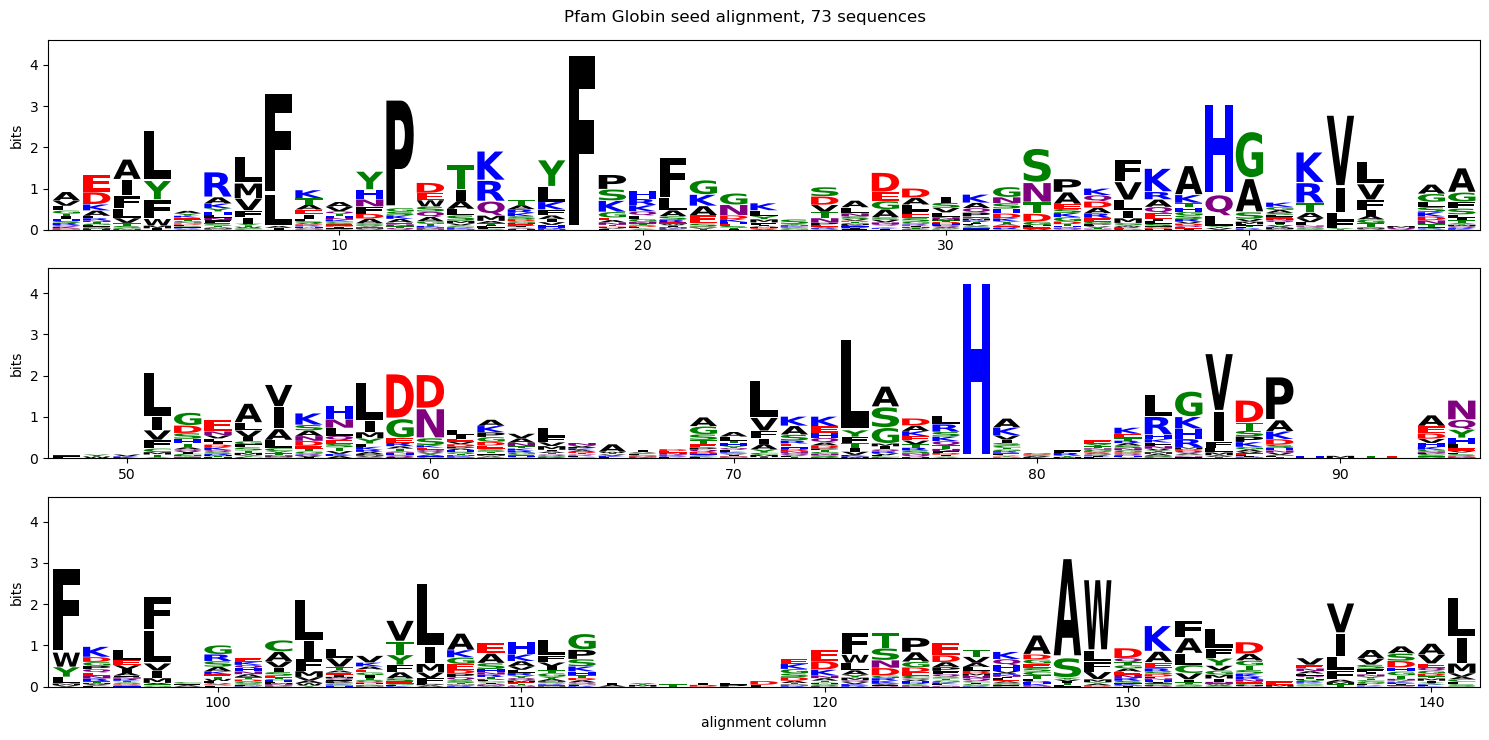

In [19]:
import logomaker

heights = freq.mul(info, axis=0)
rows = [(1, 47), (48, 94), (95, n_cols)]
fig, axes = plt.subplots(len(rows), 1, figsize=(15, 7.5))
for ax, (a, b) in zip(axes, rows):
    logomaker.Logo(heights.loc[a:b], ax=ax, color_scheme="chemistry", vpad=0.05, width=0.9)
    ax.set_xlim(a - 0.6, b + 0.6)
    ax.set_ylim(0, 4.6)
    ax.set_ylabel("bits")
axes[-1].set_xlabel("alignment column")
fig.suptitle(f"Pfam Globin seed alignment, {len(seqs)} sequences")
plt.tight_layout()
plt.show()

### 4c. Which positions are conserved, and why?

Alignment columns are not residue numbers. To talk about a position in
a protein we know, map the columns onto human beta-globin (HBB). Human
HBB is not in the seed alignment, so align it to its closest relative
there, alligator beta-globin (`HBB_ALLMI`), with Step 2's `global_align`
and a simple identity score, and read off which HBB residue sits in each
column. The numbering is that of the mature chain, without the initiator
methionine (the usual numbering for hemoglobin, as in Session 7).

In [20]:
HBB_HUMAN = ("MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTF"
             "ATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH")   # UniProt P68871

ref_name = next(n for n in globins if n.startswith("HBB_ALLMI"))
ref_row = globins[ref_name]
ref_seq = ref_row.replace("-", "")
S_map, tr_map = global_align(ref_seq, HBB_HUMAN, -2.0, lambda a, b: 1.0 if a == b else -1.0)
ali_ref, ali_hbb = traceback(ref_seq, HBB_HUMAN, S_map, tr_map)

# residue index in ref_seq -> residue index in HBB_HUMAN (index 0 is the Met, so an index is the mature number)
ref_to_hbb, i, j = {}, 0, 0
for a, b in zip(ali_ref, ali_hbb):
    if a != "-" and b != "-":
        ref_to_hbb[i] = j
    i += a != "-"
    j += b != "-"
col_to_hbb, k = {}, -1
for c, ch in enumerate(ref_row, start=1):
    if ch != "-":
        k += 1
        if k in ref_to_hbb:
            col_to_hbb[c] = ref_to_hbb[k]

print("The 10 columns with the highest information content:")
print(f"{'column':>6} {'bits':>5}  most common residue    human HBB")
for c in info.sort_values(ascending=False).index[:10]:
    top = freq.loc[c].idxmax()
    n_top = int(counts.loc[c, top])
    h = col_to_hbb.get(c)
    label = f"{HBB_HUMAN[h]}{h}" if h is not None else "-"
    print(f"{c:6d} {info[c]:5.2f}  {top} in {n_top:2d} of {int(counts.loc[c].sum()):2d}        {label}")

The 10 columns with the highest information content:
column  bits  most common residue    human HBB
    18  4.32  F in 73 of 73        F42
    78  4.32  H in 73 of 73        H92
     8  3.34  F in 54 of 73        L32
    12  3.20  P in 61 of 73        P36
   128  3.15  A in 56 of 72        A129
    39  3.09  H in 53 of 73        H63
    74  2.93  L in 56 of 73        L88
    95  2.91  F in 52 of 73        F103
    43  2.81  V in 46 of 73        V67
   129  2.63  W in 49 of 73        Y130


Two columns hold the same residue in every one of the 73 globins. Look
them up (for example in the book page, or the UniProt entry for HBB,
P68871, under "Function" and "Binding site"): what do these two residues
do in the protein? A third, His63, is conserved in most but not all
globins. In Session 6 you can find all three next to the heme in the
structure.

### 4d. Optional challenges

1. **How many sequences do you need?** Draw the logo from only 5
   randomly chosen globins (starter code below), and run it a few times.
   Which columns look conserved now that were not before, and why?
2. **Alpha versus beta.** The seed contains both alpha (`HBA...`) and
   beta (`HBB...`) chains. Build `freq` separately for the two groups and
   find the columns where their most common residues differ. These are
   candidates for the positions that make an alpha chain an alpha chain.

fully conserved columns in this sample of 5: 4  (in all 73: 2)


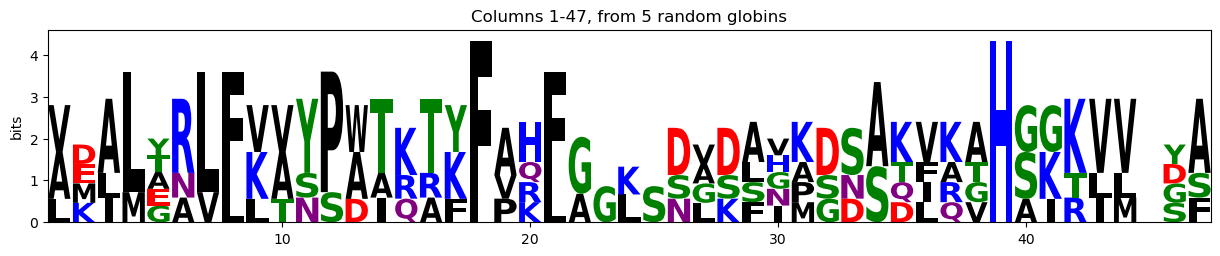

In [21]:
# Challenge 1: the same logo from only 5 random sequences
rng = np.random.default_rng()          # no seed: a new draw every run
few = [seqs[i] for i in rng.choice(len(seqs), size=5, replace=False)]
counts5 = pd.DataFrame([[sum(s[j] == a for s in few) for a in AAS] for j in range(n_cols)],
                       columns=list(AAS), index=range(1, n_cols + 1), dtype=float)
freq5 = counts5.div(counts5.sum(axis=1).replace(0, 1), axis=0)
entropy5 = -(freq5 * np.log2(freq5.where(freq5 > 0, 1))).sum(axis=1)
info5 = (np.log2(20) - entropy5) * counts5.sum(axis=1) / len(few)
print("fully conserved columns in this sample of 5:", int(((entropy5 == 0) & (counts5.sum(axis=1) == 5)).sum()),
      f" (in all {len(seqs)}: {len(conserved)})")
fig, ax = plt.subplots(figsize=(15, 2.5))
logomaker.Logo(freq5.mul(info5, axis=0).loc[1:47], ax=ax, color_scheme="chemistry", width=0.9)
ax.set_ylim(0, 4.6); ax.set_ylabel("bits"); ax.set_title("Columns 1-47, from 5 random globins")
plt.show()

## Done

Once Step 1's row checks, the traceback check and Step 4a's entropy
check all say "correct," and you've read through the real output of
Steps 2, 3 and 4, you have everything the Session 4 lab quiz on Canvas
asks for.
